
-- Airport Statistics --
1. Airport Statistics Yearly 
2. Return to Main Menu


Select an option:  1


Please enter the year to review data (from 2002 to 2024)


 2004


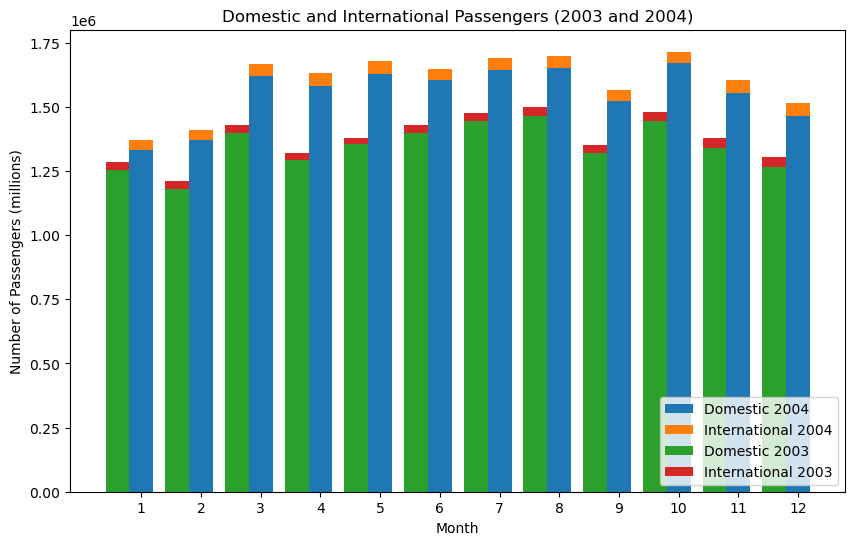

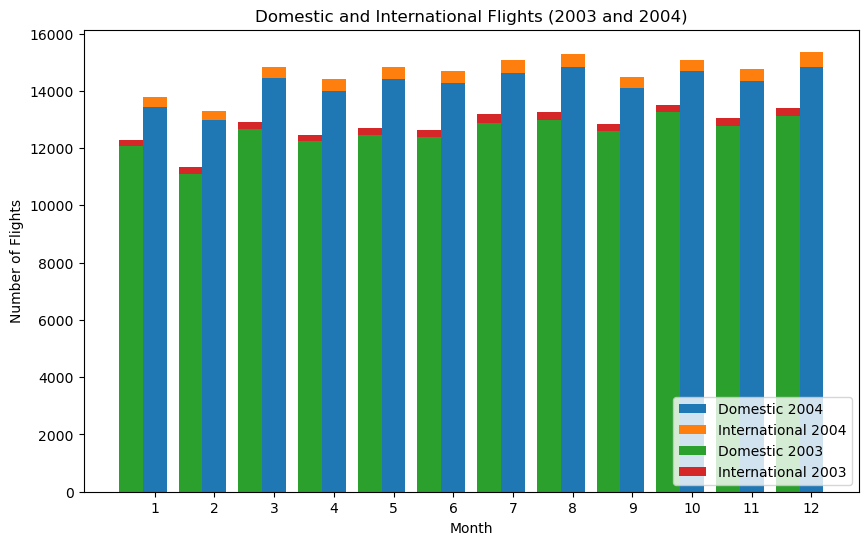

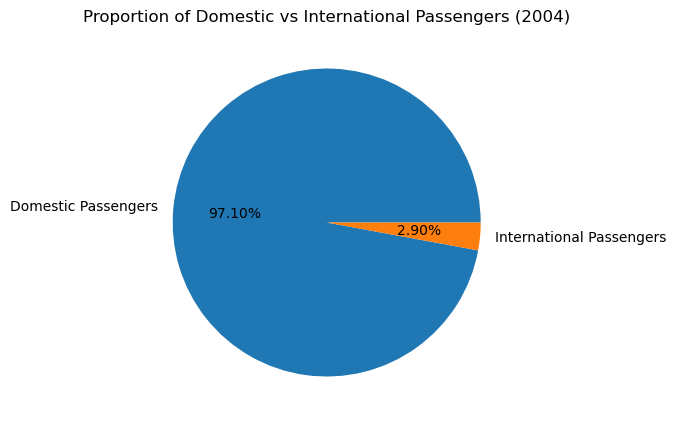


-- Airport Statistics --
1. Airport Statistics Yearly 
2. Return to Main Menu


In [ ]:
import os
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def airport_menu():
    while True:
        print("\n-- Airport Statistics --")
        print("1. Airport Statistics Yearly ")
        print("2. Return to Main Menu")
        choice = input("Select an option: ")
        # read the csv file for the data
        passengers = pd.read_csv('LV-Passengers.csv')
        flights = pd.read_csv('LV-Flights.csv')
        #Combine all data into one DataFrame
        transportation = pd.merge(passengers, flights, how = 'inner', on = ['Year','Month'])
        transportation
            
        # Data Cleaning:
        #Filter the TOTAL row 
        transportation = transportation.loc[transportation['Month'] != 'TOTAL']
        #Drop TOTAL PASSENGERS & TOTAL FLIGHTS column
        transportation = transportation.drop(['TOTAL PASSENGERS', 'TOTAL FLIGHTS'], axis = 1)
        #Remove commas and convert columns to numeric
        #Replace the NaN with median within a year
        dataCleaning = ['DOMESTIC PASSENGERS', 'INTERNATIONAL PASSENGERS', 
                            'DOMESTIC FLIGHTS', 'INTERNATIONAL FLIGHTS']
        for col in dataCleaning:
            transportation[col] = transportation[col].replace(',', '', regex=True).astype(float)
            transportation[col] = transportation.groupby('Year')[col].transform(lambda x: x.fillna(x.median()))
        if choice == '1':
            #Ask user to enter the year
            print('Please enter the year to review data (from 2002 to 2024)')
            year = int(input())
            
            #Verify the year in the DataFrame
            while int(year) not in transportation['Year'].values:
                print('Currently, only the data form 2002 to 2024 are available, please enter again:')
                year = input()
            
            #Create the mask for filtering by year
            mask = transportation['Year'] == int(year)
            data = transportation[mask]
            data
            maskHistory = transportation['Year'] == int(year) - 1
            dataHistory = transportation[maskHistory]
            
            # Ensure both datasets have the same months
            uniqueMonths = data['Month'].unique()
            
            # Reindex both data and dataHistory to match months
            data = data.set_index('Month').reindex(uniqueMonths).reset_index()
            dataHistory = dataHistory.set_index('Month').reindex(uniqueMonths).reset_index()
            
            # Fill missing values in dataHistory with zeros
            dataHistory = dataHistory.fillna(0)
            
            # Side-by-side bar chart to compare current year with previous year
            if not dataHistory.empty:  # Check if there is data for the previous year
                plt.figure(figsize=(10, 6))
                width = 0.4  # Set Bar width
                x = range(len(data['Month']))
                # Plot the input year data
                plt.bar(data['Month'], data['DOMESTIC PASSENGERS'], width = width, label='Domestic '+str(year))
                plt.bar(data['Month'], data['INTERNATIONAL PASSENGERS'], width = width, 
                        bottom=data['DOMESTIC PASSENGERS'], label='International '+str(year))
                
                # Offset x-axis for the previous year
                xHistory = [i - width for i in x]
                
                # Plot the previous year data
                plt.bar(xHistory, dataHistory['DOMESTIC PASSENGERS'], width = width, label='Domestic '+str(int(year) - 1))
                plt.bar(xHistory, dataHistory['INTERNATIONAL PASSENGERS'], width = width, 
                        bottom=dataHistory['DOMESTIC PASSENGERS'], label='International '+str(int(year) - 1))
            
            else:
                # Create stacked bar chart for passengers
                plt.figure(figsize=(6, 5))
                plt.bar(data['Month'], data['DOMESTIC PASSENGERS'], label='Domestic '+str(year))
                plt.bar(data['Month'], data['INTERNATIONAL PASSENGERS'], 
                        bottom=data['DOMESTIC PASSENGERS'], label='International '+str(year))
            
            # Customize the plot
            plt.title("Domestic and International Passengers ("+str(int(year) - 1)+" and "+str(year)+")")
            plt.xlabel("Month")
            plt.ylabel("Number of Passengers (millions)")
            plt.legend(loc='lower right')
            plt.show()

            # Side-by-side bar chart to compare current year with previous year
            if not dataHistory.empty:  # Check if there is data for the previous year
                plt.figure(figsize=(10, 6))
                width = 0.4  # Bar width
                x = range(len(data['Month']))
                # Plot current year data
                plt.bar(data['Month'], data['DOMESTIC FLIGHTS'], width = width, label='Domestic '+str(year))
                plt.bar(data['Month'], data['INTERNATIONAL FLIGHTS'], width = width, 
                        bottom=data['DOMESTIC FLIGHTS'], label='International '+str(year))
                
                # Offset x-axis for the previous year
                x_history = [i - width for i in x]
                
                # Plot previous year data
                plt.bar(x_history, dataHistory['DOMESTIC FLIGHTS'], width = width, label='Domestic '+str(int(year) - 1))
                plt.bar(x_history, dataHistory['INTERNATIONAL FLIGHTS'], width = width, 
                        bottom=dataHistory['DOMESTIC FLIGHTS'], label='International '+str(int(year) - 1))
            else:
                # Create stacked bar chart for passengers
                plt.figure(figsize=(6, 5))
                plt.bar(data['Month'], data['DOMESTIC FLIGHTS'], label='Domestic '+str(year))
                plt.bar(data['Month'], data['INTERNATIONAL FLIGHTS'], 
                        bottom=data['DOMESTIC FLIGHTS'], label='International '+str(year))
                
            # Customize the plot
            plt.title("Domestic and International Flights ("+str(int(year) - 1)+" and "+str(year)+")")
            plt.xlabel("Month")
            plt.ylabel("Number of Flights")
            plt.legend(loc='lower right')
            plt.show()

            # Calculate total domestic and international passengers for the selected year
            totalDomestic = data['DOMESTIC PASSENGERS'].sum()
            totalInternational = data['INTERNATIONAL PASSENGERS'].sum()
            
            # Create data for the pie chart
            categories = ['Domestic Passengers', 'International Passengers']
            sizes = [totalDomestic, totalInternational]
            plt.figure(figsize=(5, 5))
            plt.pie(sizes, labels=categories, autopct='%1.2f%%')
            plt.title("Proportion of Domestic vs International Passengers ("+str(year)+")")
            plt.show()
            
        elif choice == '2':
            main_menu()
            return
        else:
            print("Invalid option. Please try again.")

airport_menu()